# Interpretation of Results

This notebook presents and interprets the performance of the supervised machine learning models developed during the predictive modeling phase. The final Logistic Regression model is evaluated using visualizations and classification metrics to explain model performance and support the conclusions drawn from this study.

In [49]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import train_test_split

## Load Saved Data and Model Artifacts

Load the preprocessed dataset, saved TF-IDF vectorizer, selected Logistic Regression model, and exported model performance results from the predictive modeling phase.

In [50]:
# Define project paths
project_root = Path("..")

data_path = project_root / "data" / "processed" / "mental_health_text_preprocessed.csv"

models_dir = project_root / "models"
vectorizer_path = models_dir / "tfidf_vectorizer.joblib"
model_path = models_dir / "best_model.joblib"

results_path = project_root / "reports" / "results" / "model_performance_results.csv"

# Load the dataset and saved artifacts
df = pd.read_csv(data_path)
tfidf = joblib.load(vectorizer_path)
logistic_model = joblib.load(model_path)
results_df = pd.read_csv(results_path)

# Convert labels to integers
df["Label"] = df["Label"].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Saved model: {type(logistic_model).__name__}")

display(results_df)

Dataset shape: (15774, 8)
Vocabulary size: 23,837
Saved model: LogisticRegression


,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.883994,0.884343,0.883994,0.883802
1,Logistic Regression,0.883994,0.885841,0.883994,0.883442
2,Random Forest,0.862124,0.863631,0.862124,0.861957
3,Multinomial Naïve Bayes,0.816165,0.850259,0.816165,0.812291


## Recreate the Testing Dataset

Recreate the same training and testing split used during predictive modeling. Using the same random state and stratified sampling ensures that the saved Logistic Regression model is evaluated on the identical testing dataset used during model development.

In [51]:
# Define features and labels
X = df["TEXT_PROCESSED"]
y = df["Label"]

# Recreate the same train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Transform the text using the saved TF-IDF vectorizer
X_test_tfidf = tfidf.transform(X_test)

print(f"Testing samples: {len(X_test):,}")
print(f"Testing feature matrix shape: {X_test_tfidf.shape}")

Testing samples: 3,155
Testing feature matrix shape: (3155, 23837)


## Generate Predictions

Use the saved Logistic Regression model to generate predictions for the recreated testing dataset. These predictions will be used to create visualizations and interpret model performance.

In [52]:
# Generate predictions
predictions = logistic_model.predict(X_test_tfidf)

print("Predictions generated successfully.")

Predictions generated successfully.


## Evaluate the Final Model

Calculate the overall performance of the final Logistic Regression model using accuracy, weighted precision, weighted recall, and weighted F1-score. These metrics provide a quantitative summary of the model's predictive performance before visualizing the results.

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

In [54]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    predictions,
    average="weighted",
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=[
            "Neutral",
            "Depression",
            "Suicidal",
        ],
    )
)

Accuracy : 0.8840
Precision: 0.8858
Recall   : 0.8840
F1-Score : 0.8834

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.85      0.94      0.90      1207
  Depression       0.93      0.88      0.91       859
    Suicidal       0.89      0.82      0.85      1089

    accuracy                           0.88      3155
   macro avg       0.89      0.88      0.88      3155
weighted avg       0.89      0.88      0.88      3155



## Model Performance Comparison

Compare the overall performance of the four supervised machine learning models using accuracy, precision, recall, and F1-score. This visualization provides a concise summary of model performance and supports the selection of the final predictive model.

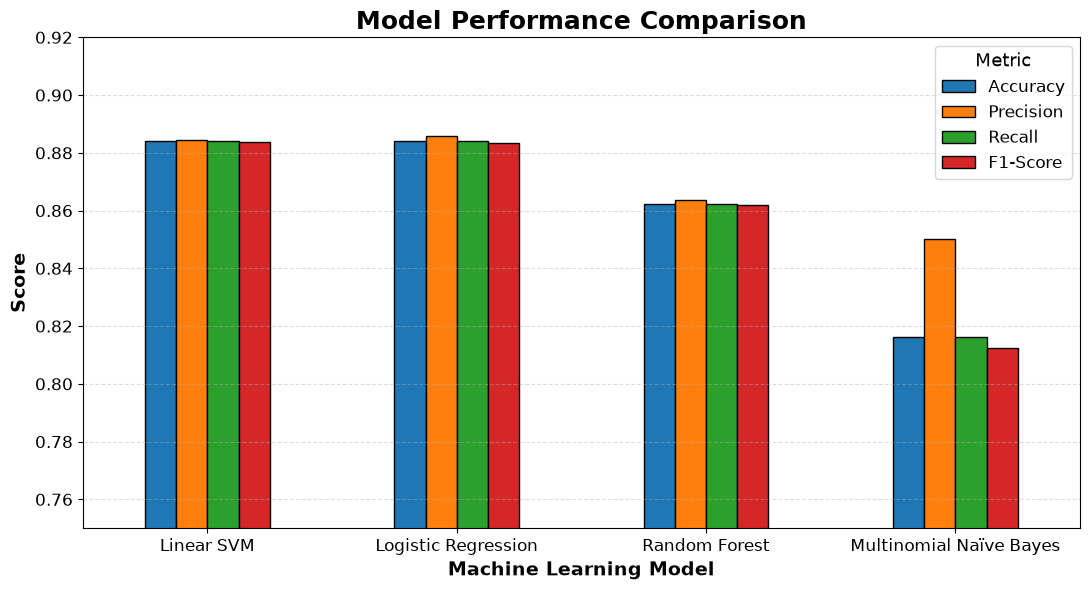

In [55]:
# Prepare the data for plotting
plot_df = results_df.set_index("Model")

# Create the chart
ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6),
    edgecolor="black",  # Black borders
    linewidth=1,
)

# Formatting
plt.title(
    "Model Performance Comparison",
    fontsize=18,
    fontweight="bold",
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=14,
    fontweight="bold",
)

plt.ylabel(
    "Score",
    fontsize=14,
    fontweight="bold",
)

plt.ylim(0.75, 0.92)

plt.xticks(
    rotation=0,
    fontsize=12,
)

plt.yticks(fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

plt.legend(
    title="Metric",
    fontsize=12,
    title_fontsize=13,
    loc="upper right",
)

plt.tight_layout()

# Save the figure
figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_dir / "Figure_6_1_Model_Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretation

Figure 6.1 shows that Logistic Regression and Linear Support Vector Machine achieved the highest overall classification accuracy (88.40%), while Random Forest (86.21%) and Multinomial Naïve Bayes (81.62%) produced lower overall performance. Although Linear SVM achieved a slightly higher weighted F1-score, Logistic Regression achieved the highest weighted precision while matching the highest overall accuracy. Based on these evaluation metrics, Logistic Regression was selected as the final predictive model because it achieved the highest weighted precision while matching the highest overall accuracy and provided good interpretability and support for probability estimates. These evaluation metrics indicate that Logistic Regression provided the best overall balance of predictive performance and interpretability for this dataset.

## Confusion Matrix

Create a confusion matrix for the selected Logistic Regression model. This visualization shows how many posts from each actual mental health category were correctly classified and where misclassifications occurred.

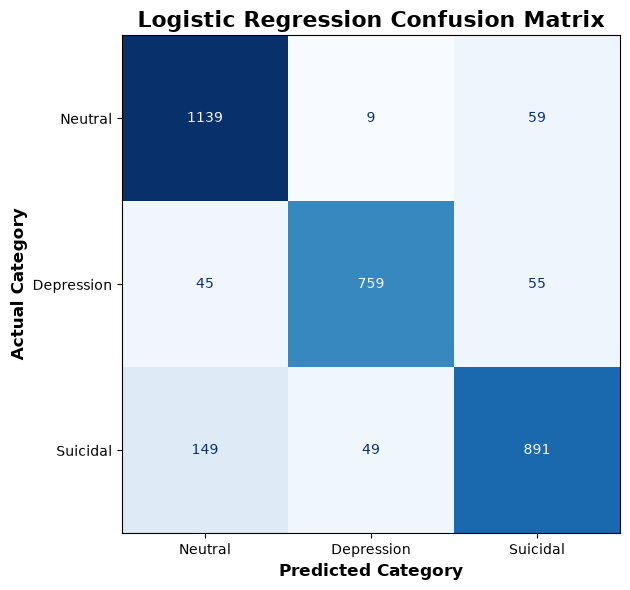

In [56]:
# Define class labels
class_names = [
    "Neutral",
    "Depression",
    "Suicidal",
]

# Create the confusion matrix display
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=class_names,
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False,
)

ax.set_title(
    "Logistic Regression Confusion Matrix",
    fontsize=16,
    fontweight="bold",
)

ax.set_xlabel(
    "Predicted Category",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylabel(
    "Actual Category",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()

# Save the figure
figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_dir / "Figure_6_2_Logistic_Regression_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretation

Figure 6.2 shows that the Logistic Regression model correctly classified most observations across all three mental health categories. The largest values appear along the main diagonal of the confusion matrix, indicating that most posts were classified correctly. Neutral and Depression posts achieved particularly strong classification performance. The largest number of misclassifications occurred when Suicidal posts were predicted as Neutral (149 cases), indicating that distinguishing some suicidal posts from neutral posts was the most challenging classification task for the model.

## Interpretation of Results

Figure 6.1 compares the overall performance of the four supervised machine learning algorithms using accuracy, weighted precision, weighted recall, and weighted F1-score. Logistic Regression and Linear Support Vector Machine achieved the highest overall classification accuracy (88.40%), while Random Forest (86.21%) and Multinomial Naïve Bayes (81.62%) produced lower overall performance. Although Linear SVM achieved a slightly higher weighted F1-score, Logistic Regression achieved the highest weighted precision while matching the highest overall accuracy. Based on these evaluation metrics, Logistic Regression was selected as the final predictive model because it provided the best overall balance of predictive performance and interpretability for this dataset.

Figure 6.2 provides additional evidence by illustrating the classification performance of the selected Logistic Regression model. The largest values occur along the main diagonal of the confusion matrix, indicating that most posts were classified correctly. Neutral and Depression posts were classified with particularly strong performance, while the largest number of misclassifications occurred when Suicidal posts were predicted as Neutral (149 cases). This indicates that distinguishing some suicidal posts from neutral posts was the most challenging classification task for the model.

## Conclusions

The evaluation results demonstrate that supervised machine learning can effectively classify mental health-related social media posts using TF-IDF feature engineering. Logistic Regression and Linear SVM achieved the strongest overall performance, each producing an overall classification accuracy of 88.40%.

Based on the evaluation metrics and confusion matrix, Logistic Regression was selected as the final predictive model because it combined strong predictive performance with high interpretability and support for probability estimates. Although some Suicidal posts were misclassified as Neutral, the confusion matrix showed that the majority of observations were classified correctly across all three mental health categories.

Overall, the evaluation metrics and confusion matrix demonstrate that combining text preprocessing, TF-IDF feature engineering, and supervised machine learning provided an effective and reproducible approach for classifying the mental health text dataset used in this study.

## Key Findings

The analysis produced the following key findings:

- Logistic Regression and Linear SVM achieved the highest overall classification accuracy (88.40%).
- Logistic Regression achieved the highest weighted precision while matching the highest overall accuracy.
- Most posts were correctly classified, as demonstrated by the large values along the confusion matrix diagonal.
- The largest classification challenge occurred when Suicidal posts were predicted as Neutral.
- Based on the evaluation metrics and confusion matrix, Logistic Regression was selected as the final predictive model.

In [58]:
# Save the classification report
classification_df = pd.DataFrame(
    classification_report(
        y_test,
        predictions,
        target_names=["Neutral", "Depression", "Suicidal"],
        output_dict=True,
    )
).transpose()

classification_path = project_root / "reports" / "results" / "classification_report.csv"

classification_df.to_csv(classification_path)

print(f"Classification report saved to: {classification_path}")

Classification report saved to: ..\reports\results\classification_report.csv
